# PART 12

Haikal Ali_1103223071_TK46GAB

# SLC 12 - Cross-Validation dan Teknik Evaluasi Model

Notebook ini dibuat berdasarkan materi **Cross-Validation and Model Evaluation Techniques**.

Materi utama:
- Introduction to cross-validation
- Advanced cross-validation methods
- Implementing cross-validation in scikit-learn
- Model selection techniques
- Evaluating model generalizability

## 1. Introduction to Cross-Validation

Cross-validation digunakan untuk menilai bagaimana model machine learning akan bekerja pada data yang belum pernah dilihat sebelumnya. Dibanding hanya memakai satu kali pembagian train-test, dataset dibagi menjadi beberapa subset. Model dilatih dan divalidasi beberapa kali agar estimasi kemampuan generalisasi menjadi lebih baik.

Pada bagian ini digunakan dua metode:
- **KFold**
- **StratifiedKFold**

Pada k-fold, nilai **k** menunjukkan jumlah fold atau subset yang dipakai untuk membagi dataset.

### Persiapan Dataset dan Library

Dataset klasifikasi dibuat menggunakan `make_classification()` dengan 500 sampel, 10 fitur, 8 fitur informatif, 2 fitur redundant, dan 2 kelas.

In [1]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [2]:
X, y = make_classification(
  n_samples=500, n_features=10, n_informative=8,
  n_redundant=2, n_classes=2, random_state=2024
)

### KFold Cross-Validation

KFold membagi data menjadi 5 bagian. Model dilatih pada 4 bagian dan diuji pada 1 bagian. Proses ini diulang sampai semua bagian pernah menjadi data uji.

In [3]:
kf = KFold(n_splits=5, shuffle=True, random_state=2024)

In [4]:
accuracies = []

for train_index, test_index in kf.split(X):
  X_train, X_test = X[train_index], X[test_index]
  y_train, y_test = y[train_index], y[test_index]

  model = LogisticRegression()
  model.fit(X_train, y_train)

  y_pred = model.predict(X_test)
  accuracies.append(accuracy_score(y_test, y_pred))

print(f"Average accuracy (KFold): {np.mean(accuracies):.3f}")

Average accuracy (KFold): 0.756


### Stratified KFold Cross-Validation

StratifiedKFold menjaga proporsi kelas pada setiap fold. Ini lebih cocok untuk masalah klasifikasi, terutama jika distribusi kelas tidak seimbang.

In [5]:
strat_kf = StratifiedKFold(
  n_splits=5, shuffle=True, random_state=2024
)

In [6]:
strat_accuracies = []

for train_index, test_index in strat_kf.split(X, y):
  X_train, X_test = X[train_index], X[test_index]
  y_train, y_test = y[train_index], y[test_index]

  model = LogisticRegression()
  model.fit(X_train, y_train)

  y_pred = model.predict(X_test)
  strat_accuracies.append(accuracy_score(y_test, y_pred))

print(f"Average accuracy (StratifiedKFold): {np.mean(strat_accuracies):.3f}")

Average accuracy (StratifiedKFold): 0.766


### Cara Kerja

Standard k-fold cross-validation membagi data menjadi beberapa bagian dengan ukuran yang hampir sama, lalu melakukan proses training dan testing berulang. Namun, untuk klasifikasi dengan kelas tidak seimbang, pembagian ini bisa menghasilkan fold yang tidak mewakili distribusi kelas sebenarnya.

Stratified k-fold mempertahankan persentase kelas pada setiap fold, sehingga evaluasi model menjadi lebih stabil dan lebih adil.

## 2. Advanced Cross-Validation Methods

Pada bagian ini digunakan dua metode lanjutan:
- **Leave-One-Out Cross-Validation (LOOCV)**
- **Nested Cross-Validation**

LOOCV berguna ketika data terbatas, karena setiap iterasi hanya menyisakan satu data sebagai data uji. Nested cross-validation digunakan untuk tuning hyperparameter tanpa menyebabkan data leakage antara proses pemilihan model dan evaluasi model.

### Persiapan Dataset dan Library

Bagian ini menggunakan dataset `load_diabetes()` dan model `Ridge`.

In [7]:
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.model_selection import (
  LeaveOneOut, GridSearchCV, cross_val_score
)
from sklearn.linear_model import Ridge

In [8]:
data = load_diabetes()
X = data.data
y = data.target

### Leave-One-Out Cross-Validation

LOOCV melatih model dengan semua data kecuali satu data, lalu satu data tersebut digunakan sebagai data uji. Proses ini dilakukan untuk setiap data.

In [9]:
loo = LeaveOneOut()
model = Ridge(alpha=1.0)

scores = cross_val_score(
  model, X, y, cv=loo,
  scoring="neg_mean_squared_error"
)

print(f"LOOCV mean MSE: {-np.mean(scores):.3f}")

LOOCV mean MSE: 3327.655


### Nested Cross-Validation

Nested cross-validation memakai inner loop untuk hyperparameter tuning dan outer loop untuk evaluasi performa model.

In [10]:
param_grid = {"alpha": [0.01, 0.1, 1, 10, 100]}

In [11]:
nested_scores = cross_val_score(
  GridSearchCV(Ridge(), param_grid, cv=5),
  X, y, cv=5
)

print(f"Nested CV mean score: {np.mean(nested_scores):.3f}")

Nested CV mean score: 0.480


### Cara Kerja

LOOCV memberikan estimasi yang hampir tidak bias, tetapi biaya komputasinya lebih tinggi karena model dilatih sebanyak jumlah data.

Nested cross-validation mencegah overfitting pada proses tuning hyperparameter karena proses tuning dan evaluasi dilakukan pada fold yang terpisah.

## 3. Implementing Cross-Validation in scikit-learn

scikit-learn menyediakan beberapa fungsi untuk cross-validation:
- `cross_val_score()`
- `cross_validate()`
- `GridSearchCV()`

Bagian ini menggunakan dataset klasifikasi dengan distribusi kelas tidak seimbang, yaitu 70% untuk kelas pertama dan 30% untuk kelas kedua.

In [12]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
  cross_val_score, cross_validate, GridSearchCV
)

In [13]:
X, y = make_classification(
  n_samples=500, n_features=10,
  weights=[0.7, 0.3], random_state=2024
)

### cross_val_score()

`cross_val_score()` digunakan untuk menghitung performa model berdasarkan satu metrik.

In [14]:
model = LogisticRegression()

scores = cross_val_score(
  model, X, y, cv=5, scoring='accuracy'
)

print(f"Mean accuracy: {np.mean(scores):.3f}")

Mean accuracy: 0.910


### cross_validate()

`cross_validate()` lebih fleksibel karena dapat menghitung beberapa metrik sekaligus.

In [15]:
results = cross_validate(
  model, X, y, cv=5,
  scoring=['accuracy', 'precision', 'recall', 'f1']
)

print(f"Mean precision: {np.mean(results['test_precision']):.3f}")
print(f"Mean recall: {np.mean(results['test_recall']):.3f}")
print(f"Mean F1: {np.mean(results['test_f1']):.3f}")

Mean precision: 0.875
Mean recall: 0.820
Mean F1: 0.845


### GridSearchCV()

`GridSearchCV()` menggabungkan cross-validation dengan pencarian hyperparameter terbaik.

In [16]:
param_grid = {"C": [0.01, 0.1, 1, 10]}

grid = GridSearchCV(
  LogisticRegression(),
  param_grid, cv=5,
  scoring='accuracy'
)

grid.fit(X, y)

print(f"Best hyperparameter (C): {grid.best_params_['C']}")
print(f"Best accuracy: {grid.best_score_:.3f}")

Best hyperparameter (C): 0.1
Best accuracy: 0.918


### Cara Kerja

`cross_val_score()` cocok untuk evaluasi cepat dengan satu metrik. `cross_validate()` digunakan ketika ingin melihat beberapa metrik sekaligus. `GridSearchCV()` digunakan untuk mencoba kombinasi hyperparameter dan memilih konfigurasi terbaik berdasarkan metrik tertentu.

Pada dataset yang tidak seimbang, akurasi tidak selalu menjadi metrik terbaik. Precision, recall, atau F1-score bisa lebih sesuai tergantung konteks kasus.

## 4. Model Selection Techniques

Model selection digunakan untuk memilih model atau konfigurasi model terbaik. Pada bagian ini digunakan:
- `GridSearchCV()`
- `RandomizedSearchCV()`

Keduanya dipakai untuk mencari nilai hyperparameter `C` terbaik pada logistic regression.

In [17]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
  GridSearchCV, RandomizedSearchCV, train_test_split
)
from sklearn.metrics import accuracy_score

In [18]:
X, y = make_classification(
  n_samples=500, n_features=10,
  weights=[0.7, 0.3], random_state=2024
)

X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.3,
  random_state=2024
)

### GridSearchCV

GridSearchCV mencoba semua kombinasi hyperparameter yang sudah ditentukan.

In [19]:
param_grid = {"C": [0.001, 0.01, 0.1, 1, 10, 100]}

grid = GridSearchCV(
  LogisticRegression(), param_grid, cv=5,
  scoring='accuracy'
)

grid.fit(X_train, y_train)

print(f"GridSearchCV best C: {grid.best_params_['C']}")

GridSearchCV best C: 0.1


### RandomizedSearchCV

RandomizedSearchCV mengambil sampel acak dari distribusi hyperparameter yang ditentukan. Cara ini sering lebih efisien dibanding grid search jika ruang pencarian besar.

In [20]:
from scipy.stats import loguniform

param_dist = {"C": loguniform(1e-3, 1e2)}

random_search = RandomizedSearchCV(
  LogisticRegression(),
  param_distributions=param_dist,
  n_iter=10, cv=5, scoring='accuracy',
  random_state=2024
)

random_search.fit(X_train, y_train)

print(f"RandomizedSearchCV best C: {random_search.best_params_['C']:.4f}")

RandomizedSearchCV best C: 0.1744


### Evaluasi Model Akhir

Model terbaik dari `RandomizedSearchCV()` digunakan untuk melakukan prediksi pada test set.

In [21]:
final_model = random_search.best_estimator_
y_pred = final_model.predict(X_test)

print(f"Final accuracy on test set: {accuracy_score(y_test, y_pred):.3f}")

Final accuracy on test set: 0.940


### Cara Kerja

GridSearchCV melakukan pencarian menyeluruh pada parameter grid. Pendekatan ini lengkap, tetapi bisa mahal secara komputasi jika jumlah parameter besar.

RandomizedSearchCV mengambil sejumlah kombinasi secara acak dari distribusi parameter. Pendekatan ini bisa lebih efisien dan tetap menghasilkan performa yang sebanding.

## 5. Evaluating Model Generalizability

Model yang bagus pada data training dan validation belum tentu selalu bagus pada data baru. Pada bagian ini digunakan:
- **Learning curve**
- **Validation curve**

Learning curve menunjukkan bagaimana performa model berubah ketika ukuran data training bertambah. Validation curve menunjukkan pengaruh nilai hyperparameter terhadap performa model.

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
  learning_curve, validation_curve
)

In [23]:
X, y = make_classification(
  n_samples=1000, n_features=20,
  weights=[0.7, 0.3], random_state=2024
)

### Learning Curve

Learning curve membandingkan skor training dan skor cross-validation pada ukuran data training yang berbeda.

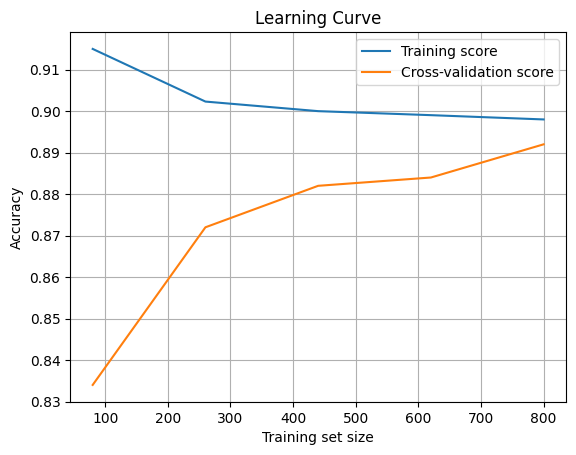

In [24]:
train_sizes, train_scores, test_scores = learning_curve(
  LogisticRegression(), X, y, cv=5,
  scoring='accuracy',
  train_sizes=np.linspace(0.1, 1.0, 5),
  random_state=2024
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.plot(train_sizes, train_mean, label='Training score')
plt.plot(train_sizes, test_mean, label='Cross-validation score')
plt.xlabel('Training set size')
plt.ylabel('Accuracy')
plt.title('Learning Curve')
plt.legend()
plt.grid(True)
plt.show()

Training score menunjukkan performa model pada data yang digunakan untuk training. Cross-validation score menunjukkan performa pada data validasi, yang berperan sebagai simulasi data baru.

Jika kedua garis mulai mendekat, model menunjukkan generalisasi yang lebih baik. Jika jaraknya jauh, model mungkin mengalami overfitting.

### Validation Curve

Validation curve menunjukkan pengaruh nilai `C` terhadap performa model logistic regression. `C` adalah inverse regularization strength.

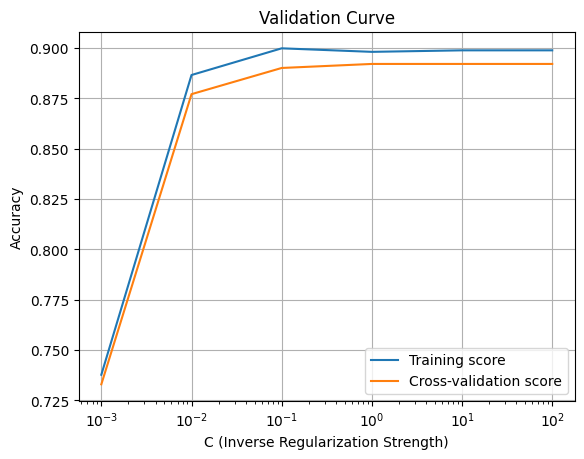

In [25]:
param_range = np.logspace(-3, 2, 6)

train_scores, test_scores = validation_curve(
  LogisticRegression(), X, y, param_name="C",
  param_range=param_range, cv=5, scoring='accuracy'
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.semilogx(param_range, train_mean, label='Training score')
plt.semilogx(param_range, test_mean, label='Cross-validation score')
plt.xlabel('C (Inverse Regularization Strength)')
plt.ylabel('Accuracy')
plt.title('Validation Curve')
plt.legend()
plt.grid(True)
plt.show()

### Cara Kerja

Learning curve membantu melihat apakah penambahan data training masih meningkatkan performa model.

Validation curve membantu melihat apakah model underfitting atau overfitting pada nilai hyperparameter tertentu. Nilai `C` kecil berarti regularisasi kuat, sedangkan nilai `C` besar berarti regularisasi lebih lemah.

## 6. Practical Exercises in Cross-Validation and Evaluation

Bagian ini berisi latihan praktik dari materi.

### Exercise 1: Cross-validating a logistic regression model

Langkah implementasi:
1. Load libraries.
2. Load dataset.
3. Cross-validate dan kumpulkan metrics.

### Exercise 2: Tuning hyperparameters with grid search

Langkah implementasi:
1. Load libraries.
2. Load dan split dataset.
3. Perform grid search.
4. Evaluate on the test set.

### Exercise 3: Assessing model generalization with learning and validation curves

Langkah implementasi:
1. Load libraries.
2. Plot learning curve.
3. Plot validation curve.